## Constant Var.

In [14]:
HAP = "/home/lapdk/Downloads/oai-kpm-hap.csv"
AUD = "/home/lapdk/Downloads/oai-kpm-aud.csv"
VID = "/home/lapdk/Downloads/oai-kpm-vid.csv"
TRACTOR = "/home/lapdk/Downloads/tractor_data.csv"

In [15]:
EMBB = [
    "/home/lapdk/Downloads/oai-kpm-embb-2025-12-06-090807.csv",
    "/home/lapdk/Downloads/oai-kpm-vid.csv"
]
MMTC = [
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-06-131814.csv",
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-06-171818.csv",
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-06-211822.csv",
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-07-011827.csv",
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-07-051831.csv",
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-07-091835.csv",
    "/home/lapdk/Downloads/oai-kpm-mmtc-2025-12-08-082610.csv"
]
URLLC = [
    "/home/lapdk/Downloads/oai-kpm-urllc-2025-12-07-103902.csv",
    "/home/lapdk/Downloads/oai-kpm-urllc-2025-12-07-143906.csv",
    "/home/lapdk/Downloads/oai-kpm-urllc-2025-12-07-183909.csv",
    "/home/lapdk/Downloads/oai-kpm-urllc-2025-12-07-223913.csv",
    "/home/lapdk/Downloads/oai-kpm-urllc-2025-12-08-023917.csv",
    "/home/lapdk/Downloads/oai-kpm-urllc-2025-12-08-063921.csv"
]

# eMBB noise, URLLC-mMTC overlap
NOISED_OVERLAP = [
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-151620.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-145936.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-095826.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-162316.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-144252.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-153305.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-113848.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-154948.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-103154.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-131912.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-101510.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-122901.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-115534.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-135241.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-133557.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-130229.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-160632.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-104836.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-142609.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-112205.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-121216.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-110521.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-092512.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-140925.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-094142.csv",
    "/home/lapdk/Downloads/noise/oai-kpm-2026-08-15-124545.csv"
]

# SmartGateway

## Data preparation with TRACTOR, UNICORN, IoT traffics

In [16]:
import pandas as pd

def load_and_concatenate(csv_list):
    """
    Reads all CSVs from a list of file paths and concatenates them.
    """
    dfs = []
    for file in csv_list:
        df = pd.read_csv(file)
        dfs.append(df)

    combined_df = pd.concat(dfs, ignore_index=True)

    # Filtering (use & and parentheses)
    clean0_df = combined_df[
        (combined_df["DRB.PdcpSduVolumeDL"] > 0) &
        (combined_df["DRB.PdcpSduVolumeUL"] > 0) &
        (combined_df["DRB.RlcSduDelayDl"] > 0) &
        (combined_df["DRB.UEThpDl"] > 0) &
        (combined_df["DRB.UEThpUl"] > 0)
    ].reset_index(drop=True)

    print("Before filtering:", combined_df.shape)
    print("After filtering:", clean0_df.shape)

    return clean0_df

In [17]:
print("EMBB metrics:")
embb = load_and_concatenate(EMBB)
embb = embb.drop_duplicates(subset=['DRB.UEThpDl', 'DRB.UEThpUl'])
print("After dropping: ", embb.shape)

print("mMTC metrics:")
mmtc = load_and_concatenate(MMTC)
mmtc = mmtc.drop_duplicates(subset=['DRB.UEThpDl', 'DRB.UEThpUl'])
print("After dropping: ", mmtc.shape)

print("URLLC metrics:")
urllc = load_and_concatenate(URLLC)
urllc = urllc.drop_duplicates(subset=['DRB.UEThpDl', 'DRB.UEThpUl'])
print("After dropping: ", urllc.shape)

print("Noised metrics:")
noise = load_and_concatenate(NOISED_OVERLAP)
noise = noise.drop_duplicates(subset=['DRB.UEThpDl', 'DRB.UEThpUl'])
print("After dropping: ", noise.shape)


EMBB metrics:
Before filtering: (10472, 11)
After filtering: (3695, 11)
After dropping:  (3328, 11)
mMTC metrics:
Before filtering: (300187, 11)
After filtering: (149694, 11)
After dropping:  (37313, 11)
URLLC metrics:
Before filtering: (140044, 11)
After filtering: (106631, 11)
After dropping:  (18982, 11)
Noised metrics:
Before filtering: (25974, 11)
After filtering: (19324, 11)
After dropping:  (19308, 11)


In [18]:
def get_basic_stats(df: pd.DataFrame):
    """
    Return basic statistics for a pandas DataFrame.
    Includes:
    - count, mean, std, min, quartiles, max
    - number of missing values
    - data types
    - number of unique values per column
    """

    stats = {}

    # Core descriptive stats
    stats["descriptive_stats"] = df.describe(include='all').transpose()

    # Missing values
    stats["missing_values"] = df.isna().sum()

    # Data types
    stats["data_types"] = df.dtypes

    # Unique counts
    stats["unique_values"] = df.nunique()

    return stats

In [19]:
stats = get_basic_stats(noise)

print("Descriptive Stats:\n", stats["descriptive_stats"])
print("\nMissing Values:\n", stats["missing_values"])
print("\nData Types:\n", stats["data_types"])
print("\nUnique Values:\n", stats["unique_values"])

Descriptive Stats:
                        count unique                         top freq  \
timestamp              19308  19308  2026-08-15T13:02:24.171537    1   
gnb_cu_cp_ue_e1ap    19308.0    NaN                         NaN  NaN   
gnb_cu_ue_f1ap       19308.0    NaN                         NaN  NaN   
ran_ue_id            19308.0    NaN                         NaN  NaN   
DRB.PdcpSduVolumeDL  19308.0    NaN                         NaN  NaN   
DRB.PdcpSduVolumeUL  19308.0    NaN                         NaN  NaN   
DRB.RlcSduDelayDl    19308.0    NaN                         NaN  NaN   
DRB.UEThpDl          19308.0    NaN                         NaN  NaN   
DRB.UEThpUl          19308.0    NaN                         NaN  NaN   
RRU.PrbTotDl         19308.0    NaN                         NaN  NaN   
RRU.PrbTotUl         19308.0    NaN                         NaN  NaN   

                            mean          std    min       25%      50%  \
timestamp                    NaN        

In [20]:
embb[['DRB.UEThpDl', 'DRB.UEThpUl', 'DRB.PdcpSduVolumeUL']].mean()

DRB.UEThpDl            2642.112308
DRB.UEThpUl              58.135033
DRB.PdcpSduVolumeUL      47.579327
dtype: float64

In [17]:
mmtc[['DRB.UEThpDl', 'DRB.UEThpUl', 'DRB.PdcpSduVolumeUL']].mean()

DRB.UEThpDl            84.813977
DRB.UEThpUl            13.841911
DRB.PdcpSduVolumeUL    10.867204
dtype: float64

In [18]:
urllc[['DRB.UEThpDl', 'DRB.UEThpUl', 'DRB.PdcpSduVolumeUL']].mean()

DRB.UEThpDl            1143.367847
DRB.UEThpUl              19.598981
DRB.PdcpSduVolumeUL      14.914024
dtype: float64

In [19]:
noise[['DRB.UEThpDl', 'DRB.UEThpUl', 'DRB.PdcpSduVolumeUL']].mean()

DRB.UEThpDl            1480.817122
DRB.UEThpUl              28.336306
DRB.PdcpSduVolumeUL      22.329501
dtype: float64

In [21]:
# add labels
embb['label'] = 0 # eMBB
mmtc['label'] = 1 # mMTC
# URLLC conditions
urllc.loc[
    (urllc['DRB.UEThpDl'] > 84) & (urllc['DRB.UEThpDl'] <= 124) &
    (urllc['DRB.UEThpUl'] > 13) & (urllc['DRB.UEThpUl'] <= 85),
    'label'
] = 2   # URLLC

urllc.loc[
    (urllc['DRB.UEThpDl'] <= 84) &
    (urllc['DRB.UEThpUl'] <= 13),
    'label'
] = 3   # URLLC-mMTC

urllc.loc[
    (urllc['DRB.UEThpDl'] > 124) &
    (urllc['DRB.UEThpUl'] > 85),
    'label'
] = 4   # URLLC-eMBB

noise['label'] = 5 # noise_eMBB_URLLC-mMTC


In [22]:
urllc['label'].value_counts()

label
3.0    2011
4.0     672
2.0      34
Name: count, dtype: int64

In [22]:
stats = get_basic_stats(urllc[urllc['label']==4])

print("Descriptive Stats:\n", stats["descriptive_stats"])
print("\nMissing Values:\n", stats["missing_values"])
print("\nData Types:\n", stats["data_types"])
print("\nUnique Values:\n", stats["unique_values"])

Descriptive Stats:
                      count unique                         top freq  \
timestamp              672    672  2025-12-07T15:21:06.477207    1   
gnb_cu_cp_ue_e1ap    672.0    NaN                         NaN  NaN   
gnb_cu_ue_f1ap       672.0    NaN                         NaN  NaN   
ran_ue_id            672.0    NaN                         NaN  NaN   
DRB.PdcpSduVolumeDL  672.0    NaN                         NaN  NaN   
DRB.PdcpSduVolumeUL  672.0    NaN                         NaN  NaN   
DRB.RlcSduDelayDl    672.0    NaN                         NaN  NaN   
DRB.UEThpDl          672.0    NaN                         NaN  NaN   
DRB.UEThpUl          672.0    NaN                         NaN  NaN   
RRU.PrbTotDl         672.0    NaN                         NaN  NaN   
RRU.PrbTotUl         672.0    NaN                         NaN  NaN   
label                672.0    NaN                         NaN  NaN   

                             mean          std     min       25%     

In [23]:
import numpy as np
import pandas as pd

EPS = 1e-6
W = 5

def add_engineered_features(df, cold_start="drop"):
    """
    Add engineered features to a single SOURCE dataframe.
    Sorts by [ran_ue_id, timestamp] first so windows are always
    chronological per UE, regardless of incoming row order.

    cold_start : "drop"    -> remove first W-1 rows per UE (no full window)
                 "partial" -> keep them, compute on min_periods=1

    Returns a new dataframe with engineered columns added.
    """
    df = df.copy()

    # ---- ensure chronological order per UE ----
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["ran_ue_id", "timestamp"]).reset_index(drop=True)

    # ---- stateless ratios (order-independent) ----
    # df["thp_ul_dl_ratio"] = df["DRB.UEThpUl"] / (df["DRB.UEThpDl"] + EPS)
    df["prb_ul_per_thp"]  = df["RRU.PrbTotUl"] / (df["DRB.UEThpUl"] + EPS)
    # df["prb_dl_per_thp"]  = df["RRU.PrbTotDl"] / (df["DRB.UEThpDl"] + EPS)

    # ---- windowed features (per UE, trailing W, never cross UE) ----
    min_periods = W if cold_start == "drop" else 1
    g_delay = df.groupby("ran_ue_id")["DRB.RlcSduDelayDl"]
    g_thp   = df.groupby("ran_ue_id")["DRB.UEThpDl"]

    df["delay_median_w5"] = g_delay.transform(
        lambda s: s.rolling(W, min_periods=min_periods).median())

    roll_mean = g_thp.transform(
        lambda s: s.rolling(W, min_periods=min_periods).mean())
    roll_std = g_thp.transform(
        lambda s: s.rolling(W, min_periods=min_periods).std())
    df["thp_dl_cv_w5"] = roll_std / (roll_mean + EPS)

    df["thp_dl_range_w5"] = g_thp.transform(
        lambda s: s.rolling(W, min_periods=min_periods).max()
                  - s.rolling(W, min_periods=min_periods).min())

    # ---- cold-start handling ----
    if cold_start == "drop":
        windowed = ["delay_median_w5", "thp_dl_cv_w5",
                    "thp_dl_range_w5"
        ]
        df = df.dropna(subset=windowed).reset_index(drop=True)
    else:
        df["thp_dl_cv_w5"] = df["thp_dl_cv_w5"].fillna(0.0)

    return df

In [24]:
# Concatenate vertically
# combined_df = pd.concat([embb, mmtc[:3695], urllc[:3695]], ignore_index=True)
# combined_df = pd.concat([embb, urllc[urllc['label']==3]], ignore_index=True) #0-3
# combined_df = pd.concat([embb, mmtc], ignore_index=True) # 0-1
# combined_df = pd.concat([mmtc, urllc[urllc['label']==4]], ignore_index=True) #1-4
# combined_df = pd.concat([urllc[urllc['label']==3], urllc[urllc['label']==4]], ignore_index=True) #3-4
# combined_df = pd.concat([embb, mmtc, urllc[urllc['label']==3]], ignore_index=True) #0-1-3
# combined_df = pd.concat([embb, mmtc, urllc[urllc['label']==3], urllc[urllc['label']==4]], ignore_index=True) #0-1-3-4
# combined_df = pd.concat([embb, mmtc, urllc[urllc['label']==4], noise], ignore_index=True) #0-1-4-5

embb_fe  = add_engineered_features(embb)
mmtc_fe  = add_engineered_features(mmtc)
l4_fe    = add_engineered_features(urllc[urllc["label"] == 4])
noise_fe = add_engineered_features(noise)

combined_df = pd.concat([embb_fe, mmtc_fe, l4_fe, noise_fe], ignore_index=True)

# Shuffle the combined data
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

combined_df.head()

,timestamp,gnb_cu_cp_ue_e1ap,gnb_cu_ue_f1ap,ran_ue_id,DRB.PdcpSduVolumeDL,DRB.PdcpSduVolumeUL,DRB.RlcSduDelayDl,DRB.UEThpDl,DRB.UEThpUl,RRU.PrbTotDl,RRU.PrbTotUl,label,prb_ul_per_thp,delay_median_w5,thp_dl_cv_w5,thp_dl_range_w5
0,2025-12-07 06:35:13.353929,1.0,1,1,59.0,9.0,95.00,61.81,11.69,2117,2015,1.0,172.369532,92.50,0.372742,70.27
1,2026-08-15 14:01:06.706857,1.0,1,1,63.0,1.0,116.17,79.35,3.05,2739,1387,5.0,454.753949,84.67,0.333481,83.36
2,2025-12-07 00:59:13.353631,1.0,1,1,50.0,8.0,244.62,56.13,10.00,1870,2133,1.0,213.299979,217.17,0.488200,99.46
3,2026-08-15 13:24:47.995104,1.0,1,1,758.0,1.0,102.53,766.98,3.58,1568,980,5.0,273.742940,102.53,0.090840,183.26
4,2025-12-07 09:09:12.355778,1.0,1,1,39.0,6.0,357.31,41.18,8.42,1481,2147,1.0,254.988093,353.52,0.357108,56.32


In [25]:
combined_df.columns

Index(['timestamp', 'gnb_cu_cp_ue_e1ap', 'gnb_cu_ue_f1ap', 'ran_ue_id',
       'DRB.PdcpSduVolumeDL', 'DRB.PdcpSduVolumeUL', 'DRB.RlcSduDelayDl',
       'DRB.UEThpDl', 'DRB.UEThpUl', 'RRU.PrbTotDl', 'RRU.PrbTotUl', 'label',
       'prb_ul_per_thp', 'delay_median_w5', 'thp_dl_cv_w5', 'thp_dl_range_w5'],
      dtype='object')

In [26]:
stats = get_basic_stats(combined_df)

print("Descriptive Stats:\n", stats["descriptive_stats"])
print("\nMissing Values:\n", stats["missing_values"])
print("\nData Types:\n", stats["data_types"])
print("\nUnique Values:\n", stats["unique_values"])

Descriptive Stats:
                        count                           mean  \
timestamp              60605  2026-02-24 20:53:10.825309184   
gnb_cu_cp_ue_e1ap    60605.0                            1.0   
gnb_cu_ue_f1ap       60605.0                            1.0   
ran_ue_id            60605.0                            1.0   
DRB.PdcpSduVolumeDL  60605.0                     718.115024   
DRB.PdcpSduVolumeUL  60605.0                      18.301345   
DRB.RlcSduDelayDl    60605.0                     246.599828   
DRB.UEThpDl          60605.0                     726.700422   
DRB.UEThpUl          60605.0                      22.980937   
RRU.PrbTotDl         60605.0                    3676.905156   
RRU.PrbTotUl         60605.0                    1980.899249   
label                60605.0                       2.252306   
prb_ul_per_thp       60605.0                     180.070586   
delay_median_w5      60605.0                     194.168636   
thp_dl_cv_w5         60605.0       

In [27]:
def convert_kbps_to_mbps(x):
    try:
        return float(x) / 1000.0
    except Exception:
        return None

cols = ['DRB.UEThpDl', 'DRB.UEThpUl']
combined_df[cols] = combined_df[cols].map(convert_kbps_to_mbps)

In [28]:
def convert_kb_to_mbps(x):
    try:
        return float(x) / 1000.0
    except Exception:
        return None
cols = ['DRB.PdcpSduVolumeDL', 'DRB.PdcpSduVolumeUL']
combined_df[cols] = combined_df[cols].map(convert_kb_to_mbps)

In [29]:
combined_df.head()

,timestamp,gnb_cu_cp_ue_e1ap,gnb_cu_ue_f1ap,ran_ue_id,DRB.PdcpSduVolumeDL,DRB.PdcpSduVolumeUL,DRB.RlcSduDelayDl,DRB.UEThpDl,DRB.UEThpUl,RRU.PrbTotDl,RRU.PrbTotUl,label,prb_ul_per_thp,delay_median_w5,thp_dl_cv_w5,thp_dl_range_w5
0,2025-12-07 06:35:13.353929,1.0,1,1,0.059,0.009,95.00,0.06181,0.01169,2117,2015,1.0,172.369532,92.50,0.372742,70.27
1,2026-08-15 14:01:06.706857,1.0,1,1,0.063,0.001,116.17,0.07935,0.00305,2739,1387,5.0,454.753949,84.67,0.333481,83.36
2,2025-12-07 00:59:13.353631,1.0,1,1,0.050,0.008,244.62,0.05613,0.01000,1870,2133,1.0,213.299979,217.17,0.488200,99.46
3,2026-08-15 13:24:47.995104,1.0,1,1,0.758,0.001,102.53,0.76698,0.00358,1568,980,5.0,273.742940,102.53,0.090840,183.26
4,2025-12-07 09:09:12.355778,1.0,1,1,0.039,0.006,357.31,0.04118,0.00842,1481,2147,1.0,254.988093,353.52,0.357108,56.32


In [30]:
combined_df = combined_df[combined_df['label'].notna()]
combined_df = combined_df[combined_df['label']!=2]
combined_df["label"].value_counts()

label
1.0    37309
5.0    19304
0.0     3324
4.0      668
Name: count, dtype: int64

In [31]:
print("Final data: ", combined_df.shape)

Final data:  (60605, 16)


## Training

In [3]:
import sklearn
print(sklearn.__version__) # 1.6.1

1.6.1


### Heuristic

##### Set up

In [7]:
"""
Implementation of "A New Heuristic for the Data Clustering Problem"
(UMAIR F. SIDDIQI, SADIQ M. SAIT) - Python translation / end-to-end.

Notes:
- Input data must be numeric (float). Columns/features are assumed continuous.
- Recommended: scale/standardize inputs before calling (e.g., sklearn.preprocessing.StandardScaler).
- Defaults for parameters follow the paper: alpha=300, beta=10, delta=0.01, pm=0.01, B=-0.2
"""

import numpy as np
from sklearn.metrics import calinski_harabasz_score
from typing import Tuple, Optional, List



def dunn_index(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Dunn Index:
    DI = min inter-cluster distance / max intra-cluster distance (diameter).
    Larger DI is better.
    """
    labels = np.asarray(labels)
    clusters = [X[labels == lbl] for lbl in np.unique(labels)]

    # if any cluster empty or only one cluster, DI undefined -> return 0
    if len(clusters) <= 1:
        return 0.0

    # compute diameters (intra-cluster max distance)
    max_intracluster = 0.0
    for C in clusters:
        if C.shape[0] <= 1:
            diam = 0.0
        else:
            dists = pairwise_distances(C, C)
            diam = dists.max()
        if diam > max_intracluster:
            max_intracluster = diam

    # compute minimum inter-cluster distance (min distance between any two points from different clusters)
    min_inter = float('inf')
    for i in range(len(clusters)):
        Ci = clusters[i]
        for j in range(i+1, len(clusters)):
            Cj = clusters[j]
            if Ci.shape[0] == 0 or Cj.shape[0] == 0:
                continue
            dists = pairwise_distances(Ci, Cj)
            curmin = dists.min()
            if curmin < min_inter:
                min_inter = curmin

    if max_intracluster == 0:
        return float('inf') if min_inter > 0 else 0.0

    return min_inter / max_intracluster

def pairwise_distances(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Compute pairwise Euclidean distances between rows of A and rows of B."""
    # efficient vectorized calculation
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b
    aa = np.sum(A**2, axis=1)[:, None]
    bb = np.sum(B**2, axis=1)[None, :]
    return np.sqrt(np.maximum(aa + bb - 2 * A.dot(B.T), 0.0))

# -------------------------
# helper: assign points to centroids
# -------------------------
def assign_points(X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """
    Assign each point to nearest centroid (Euclidean).
    Returns labels array of shape (n_samples,)
    """
    # compute distances
    dists = pairwise_distances(X, centroids)  # (n_samples, K)
    labels = np.argmin(dists, axis=1)
    return labels

# -------------------------
# first part: greedy algorithm to select centroids as actual data-points
# -------------------------
def greedy_select_centroids_as_points(X, K, alpha, beta, objective_fn, random_state=None):
    """
    Greedy selection of centroids among data points.
    Only minimal and necessary fixes applied:
    - After assigning labels, check if `labels` has < 2 clusters.
    - If yes, skip evaluation for this candidate.
    - This prevents CH / Dunn score crashes.
    """
    rng = np.random.default_rng(random_state)
    N = X.shape[0]

    # ---- 1. Pick first centroid randomly ----
    idx0 = rng.integers(0, N)
    centroids = [X[idx0]]

    # ---- 2. Select remaining K-1 centroids greedily ----
    while len(centroids) < K:
        best_point = None
        best_val = -np.inf

        for i in range(N):
            candidate = X[i]

            # Prevent selecting the same exact point twice
            if any(np.allclose(candidate, c) for c in centroids):
                continue

            trial_centroids = np.vstack([centroids, candidate])

            # Assign labels
            labels = assign_points(X, trial_centroids)

            # --- FIX: If only 1 cluster formed, skip this candidate ---
            if len(np.unique(labels)) < 2:
                continue

            # Evaluate objective
            val = objective_fn(X, labels)

            if val > best_val:
                best_val = val
                best_point = candidate

        # If nothing valid found (should not happen), break gracefully
        if best_point is None:
            break

        centroids.append(best_point)

    return np.array(centroids)


# -------------------------
# second part: single-solution heuristic (genes = centroid attributes)
# -------------------------
def single_solution_heuristic(
    X: np.ndarray,
    initial_centroids: np.ndarray,
    K: int,
    objective: str = "CHI",   # "CHI" or "DI"
    max_iter: int = 1000,
    delta: float = 0.01,
    pm: float = 0.01,
    B: float = -0.2,
    random_state: Optional[int] = None,
    verbose: bool = False
) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    rng = np.random.RandomState(random_state)
    n, m = X.shape
    centroids = initial_centroids.copy()
    history = np.ones_like(centroids, dtype=float)
    if objective.upper() == "CHI":
        obj_fn = calinski_harabasz_score
    elif objective.upper() == "DI":
        obj_fn = dunn_index
    else:
        raise ValueError("objective must be 'CHI' or 'DI'")

    labels = assign_points(X, centroids)
    f_current = obj_fn(X, labels)
    history_obj = [f_current]

    lj = X.min(axis=0)
    uj = X.max(axis=0)

    for iteration in range(max_iter):
        labels = assign_points(X, centroids)
        Cm = np.zeros_like(centroids)
        for j in range(K):
            pts = X[labels == j]
            Cm[j] = pts.mean(axis=0) if pts.shape[0] > 0 else centroids[j]

        one_j = centroids - Cm
        Vj = one_j / history
        Vj_abs = np.abs(Vj)
        maxVj = Vj_abs.max(axis=1, keepdims=True)
        maxVj[maxVj == 0] = 1.0
        fj = Vj_abs / maxVj

        selection_mask = np.zeros_like(fj, dtype=bool)
        for i in range(K):
            for j in range(m):
                prob = np.clip(1.0 - fj[i, j] + B, 0.0, 1.0)
                if rng.rand() < prob:
                    selection_mask[i, j] = True

        improved_in_iter = False
        gene_indices = [(i, j) for i in range(K) for j in range(m) if selection_mask[i, j]]
        rng.shuffle(gene_indices)

        for (ci, aj) in gene_indices:
            cj = centroids[ci, aj]
            tl = (cj - lj[aj]) / 2.0
            tu = (uj[aj] - cj) / 2.0
            c_prime = rng.uniform(cj - tl, cj + tu)

            centroids_candidate = centroids.copy()
            centroids_candidate[ci, aj] = c_prime
            labels_candidate = assign_points(X, centroids_candidate)

            # === NEW: skip candidate if objective errors ===
            try:
                f1 = obj_fn(X, labels_candidate)
            except ValueError:
                history[ci, aj] += 1.0
                continue

            rel_change = abs(f_current - f1) / abs(f_current) if f_current != 0 else 0.0

            accept = False
            if f1 >= f_current:
                accept = True
            elif rel_change <= delta and rng.rand() < pm:
                accept = True

            if accept:
                centroids = centroids_candidate
                labels = labels_candidate
                f_current = f1
                improved_in_iter = True

            history[ci, aj] += 1.0

        history_obj.append(f_current)
        if verbose and (iteration % max(1, max_iter//10)) == 0:
            print(f"Iter {iteration:4d}: objective={f_current:.6g}, selected_genes={len(gene_indices)}")

        if len(history_obj) > 50 and history_obj[-1] <= history_obj[-51]:
            if verbose:
                print("No improvement in last 50 iterations -> stopping early.")
            break

    final_labels = assign_points(X, centroids)
    return centroids, final_labels, history_obj

In [8]:
import numpy as np
import pandas as pd
import itertools
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import calinski_harabasz_score, f1_score, recall_score
from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# 1. Log transform variants
# =====================================================
def log1p_transform(x):
    return np.log1p(x)

def log10p_transform(x):
    return np.log10(x + 1)

def sqrt_transform(x):
    return np.sqrt(x)

LOG_FUNCS = {
    "log1p": log1p_transform,
    "log10p": log10p_transform,
    "sqrt": sqrt_transform,
}

# =====================================================
# 2. Scalers
# =====================================================
SCALERS = {
    "standard": StandardScaler,
    "robust":   RobustScaler,
    "minmax":   MinMaxScaler,
}

# =====================================================
# 3. Feature Preprocessing — SELECTIVE log
# =====================================================
def prepare_features(X, log_method, scaler_cls, log_cols=None):
    """
    Apply log transform to log_cols only, then scale ALL columns.

    log_cols : list of column names to log-transform.
               If None, logs every column (original behavior).
    """
    X = X.copy()

    # default = log everything (backward compatible)
    if log_cols is None:
        log_cols = list(X.columns)

    logf = LOG_FUNCS[log_method]
    for col in log_cols:                      # <-- CHANGED: only selected cols
        X[col] = logf(X[col])

    scaler = scaler_cls()
    Xs = scaler.fit_transform(X)              # scale all columns
    return Xs, scaler


# =====================================================
# Balance the TRAINING set only (fit on balanced, evaluate on real)
# =====================================================
def balance_training_set(X_train, y_train, per_class=None, random_state=0):
    """
    Downsample majority classes / keep minority classes so the heuristic
    has density on every class. Evaluate later on the ORIGINAL val/test.

    per_class : target samples per class. Default = size of smallest class
                (full balance). Set larger to keep more majority data while
                still lifting the rare classes' relative weight.
    """
    rng = np.random.RandomState(random_state)
    y_train = np.asarray(y_train)
    X_arr = X_train.reset_index(drop=True)

    classes, counts = np.unique(y_train, return_counts=True)
    if per_class is None:
        per_class = counts.min()          # full balance -> 668 each here

    idx_keep = []
    for c in classes:
        idx_c = np.where(y_train == c)[0]
        if len(idx_c) > per_class:
            idx_c = rng.choice(idx_c, size=per_class, replace=False)
        idx_keep.append(idx_c)
    idx_keep = np.concatenate(idx_keep)
    rng.shuffle(idx_keep)

    return X_arr.iloc[idx_keep].reset_index(drop=True), y_train[idx_keep]


# ===============================
# Compute Accuracy for Heuristic
# ===============================

def compute_accuracy_heuristic(X, y, log_method, scaler, centroids, centroid_to_class, log_cols=None):
    X_proc = X.copy()

    if log_cols is None:
        log_cols = list(X_proc.columns)

    logf = LOG_FUNCS[log_method]
    for col in log_cols:                      # <-- CHANGED: identical selective log
        X_proc[col] = logf(X_proc[col])

    X_scaled = scaler.transform(X_proc)

    dists = np.linalg.norm(X_scaled[:, None] - centroids[None, :], axis=2)
    labels = np.argmin(dists, axis=1)

    preds = centroid_to_class[labels]
    accuracy = np.mean(preds == y)
    return accuracy

# a prediction function factored out of old compute_accuracy_heuristic
def predict_heuristic(X, log_method, scaler, centroids, centroid_to_class, log_cols=None):
    """Transform X identically to training, assign to nearest centroid, map to class."""
    X_proc = X.copy()
    if log_cols is None:
        log_cols = list(X_proc.columns)
    logf = LOG_FUNCS[log_method]
    for col in log_cols:
        X_proc[col] = logf(X_proc[col])
    X_scaled = scaler.transform(X_proc)
    dists = np.linalg.norm(X_scaled[:, None] - centroids[None, :], axis=2)
    nearest = np.argmin(dists, axis=1)
    return centroid_to_class[nearest]

# ===============================
# Main Clustering Runner
# ===============================

def run_clustering(
    Xs,            # preprocessed (log + scaled) features
    K,
    alpha=300,
    beta=10,
    objective="CHI",
    max_iter=500,
    delta=0.01,
    pm=0.01,
    B=-0.2,
    random_state=42,
    verbose=False
):
    """
    Run the full two-stage heuristic clustering algorithm on preprocessed dataset Xs.

    NOTE:
        Xs MUST be already log-transformed and scaled.
        This function now does NOT do any preprocessing internally.
        This is required for grid search.

    Returns:
        centroids_final : ndarray (K, n_features)
        labels_final    : ndarray (n_samples,)
        history         : list of objective values
    """
    # --- Stage 1: Greedy centroid selection ---
    initial_centroids = greedy_select_centroids_as_points(
        Xs,
        K=K,
        alpha=alpha,
        beta=beta,
        objective_fn=calinski_harabasz_score if objective=="CHI" else dunn_index,
        random_state=random_state
    )
    # initial_centroids = best_params['kmeans'].cluster_centers_
    print("Initial centroids: ", initial_centroids)
    # --- Stage 2: Single-solution heuristic ---
    centroids_final, labels_final, history = single_solution_heuristic(
        Xs,
        initial_centroids,
        K=K,
        objective=objective,
        max_iter=max_iter,
        delta=delta,
        pm=pm,
        B=B,
        random_state=random_state,
        verbose=verbose
    )

    return centroids_final, labels_final, history

# =====================================================
# Grid search: Hungarian mapping + macro-F1 selection + per-class recall
# =====================================================
def grid_search_heuristic(
    X_train, y_train,
    X_val, y_val,
    K_values,
    log_methods,
    scaler_names,
    objectives=["CHI"],
    max_iter_values=[500],
    delta_values=[0.01],
    pm_values=[0.01],
    B_values=[-0.2],
    log_cols=None,
    select_metric="macro_f1"      # what best_cfg optimizes: "macro_f1" or "acc"
):
    best_cfg = None
    best_score = -1
    best_models = None
    results = []

    y_train = np.asarray(y_train)
    y_val = np.asarray(y_val)
    classes = np.unique(y_train)                 # e.g. [0,1,4,5]
    n_classes = len(classes)

    for (K, log_method, scaler_name, objective, max_iter, delta, pm, B) in itertools.product(
        K_values, log_methods, scaler_names, objectives,
        max_iter_values, delta_values, pm_values, B_values
    ):
        print(f"\nK={K}, log={log_method}, scaler={scaler_name}, obj={objective}, "
              f"iter={max_iter}, pm={pm}, B={B}")

        # === 1. Preprocess (selective log) ===
        Xs_train, scaler = prepare_features(
            X_train, log_method, SCALERS[scaler_name], log_cols=log_cols
        )

        # === 2. Train heuristic ===
        centroids, labels, history = run_clustering(
            Xs_train, K=K, objective=objective,
            max_iter=max_iter, delta=delta, pm=pm, B=B, verbose=False
        )

        # === 3. Build class prototypes in the SAME transformed space ===
        protos = np.vstack([
            Xs_train[y_train == c].mean(axis=0, keepdims=True) for c in classes
        ])
        sims = cosine_similarity(centroids, protos)      # (K, n_classes)

        # === 4. Assign centroids -> classes ===
        if K == n_classes:
            # Hungarian: force one-to-one so every class gets a centroid.
            # linear_sum_assignment minimizes, so negate similarity.
            row, col = linear_sum_assignment(-sims)
            centroid_to_class = np.empty(K, dtype=classes.dtype)
            centroid_to_class[row] = classes[col]
        else:
            # K != n_classes: fall back to argmax (multiple centroids per class allowed)
            centroid_to_class = classes[np.argmax(sims, axis=1)]
        print("  centroid->class:", centroid_to_class)

        # === 5. Predict on validation (selective log, identical transform) ===
        preds_val = predict_heuristic(
            X_val, log_method, scaler, centroids, centroid_to_class, log_cols=log_cols
        )

        # === 6. Metrics: overall acc, macro-F1, per-class recall ===
        acc = np.mean(preds_val == y_val)
        macro_f1 = f1_score(y_val, preds_val, labels=classes, average="macro",
                            zero_division=0)
        rec = recall_score(y_val, preds_val, labels=classes, average=None,
                           zero_division=0)
        rec_str = "  ".join(f"{int(c)}:{r:.2f}" for c, r in zip(classes, rec))
        print(f"  acc={acc:.4f}  macro_f1={macro_f1:.4f}  recall[{rec_str}]")

        row_res = {
            "K": K, "log": log_method, "scaler": scaler_name,
            "objective": objective, "max_iter": max_iter,
            "delta": delta, "pm": pm, "B": B,
            "acc": acc, "macro_f1": macro_f1,
        }
        for c, r in zip(classes, rec):
            row_res[f"recall_{int(c)}"] = r
        results.append(row_res)

        score = macro_f1 if select_metric == "macro_f1" else acc
        if score > best_score:
            best_score = score
            best_cfg = (K, log_method, scaler_name, objective, max_iter, delta, pm, B)
            best_models = (scaler, centroids, centroid_to_class)

    return best_cfg, best_score, best_models, pd.DataFrame(results)

##### 0145 4-URLLC-eMBB vs 5-noised-URLLC-mMTC

In [32]:
df_0145 = combined_df[combined_df['label'].isin([0, 1, 4, 5])].copy()
df_0145['label'].value_counts()

label
1.0    37309
5.0    19304
0.0     3324
4.0      668
Name: count, dtype: int64

In [33]:
df_0145.to_csv("./df_0145.csv", index=0)

In [10]:
import pandas as pd
df_0145 = pd.read_csv("./df_0145.csv")
df_0145['label'].value_counts()

label
1.0    37309
5.0    19304
0.0     3324
4.0      668
Name: count, dtype: int64

In [36]:
from sklearn.model_selection import train_test_split

K_values = [4]
log_methods = ["log1p"]
scaler_names = ["standard"]

objectives = ["CHI"]

X = df_0145[['DRB.UEThpDl', 'DRB.UEThpUl', 'prb_ul_per_thp', 'delay_median_w5', 'thp_dl_cv_w5', 'thp_dl_range_w5']]

y = df_0145['label']

log_cols = ['DRB.UEThpDl', 'DRB.UEThpUl', 'delay_median_w5', 'thp_dl_range_w5']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.10, random_state=0, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp
)

print(f"Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# --- balance ONLY the training set; val/test stay at the real distribution ---
X_train_bal, y_train_bal = balance_training_set(X_train, y_train, per_class=3000)
print("Balanced train counts:", np.unique(y_train_bal, return_counts=True))


best_cfg, best_val_acc, best_models, results_df = grid_search_heuristic(
    X_train_bal, y_train_bal,
    X_val, y_val,
    K_values,
    log_methods,
    scaler_names,
    objectives,
    max_iter_values=[100],
    delta_values=[0.01],
    pm_values=[0.03],
    B_values=[-0.5],
    log_cols=log_cols
)

# Testing K=3, log=log1p, scaler=minmax, obj=CHI, iter=100, delta=0.01, pm=0.03, B=-0.5
# Initial centroids:  [[0.01679747 0.00162053 0.19372908 0.20908028 0.17724197]
#  [0.20571907 0.00478119 0.10696318 0.18631399 0.02888042]
#  [0.01970942 0.0024664  0.18191539 0.22986514 0.15087076]]
# Centroid to class mapping: [1. 5. 1.]
#  → val_acc = 0.8155

# Testing K=3, log=log10p, scaler=minmax, obj=CHI, iter=100, delta=0.01, pm=0.03, B=-0.5
# Initial centroids:  [[0.01679747 0.00162053 0.19372908 0.20908028 0.17724197]
#  [0.20571907 0.00478119 0.10696318 0.18631399 0.02888042]
#  [0.01970942 0.0024664  0.18191539 0.22986514 0.15087076]]
# Centroid to class mapping: [1. 5. 1.]
#  → val_acc = 0.8155

# Testing K=4, log=log10p, scaler=minmax, obj=CHI, iter=100, delta=0.01, pm=0.03, B=-0.5
# Initial centroids:  [[0.01679747 0.00162053 0.19372908 0.20908028 0.17724197]
#  [0.20571907 0.00478119 0.10696318 0.18631399 0.02888042]
#  [0.01970942 0.0024664  0.18191539 0.22986514 0.15087076]
#  [0.01937177 0.00219496 0.16825464 0.21534055 0.1434889 ]]
# Centroid to class mapping: [1. 5. 1. 1.]
#  → val_acc = 0.8142

# Testing K=4, log=log1p, scaler=minmax, obj=CHI, iter=100, delta=0.01, pm=0.03, B=-0.5
# Initial centroids:  [[0.01679747 0.00162053 0.19372908 0.20908028 0.17724197]
#  [0.20571907 0.00478119 0.10696318 0.18631399 0.02888042]
#  [0.01970942 0.0024664  0.18191539 0.22986514 0.15087076]
#  [0.01937177 0.00219496 0.16825464 0.21534055 0.1434889 ]]
# Centroid to class mapping: [1. 5. 1. 1.]
#  → val_acc = 0.8142

Train=54544, Val=3030, Test=3031
Balanced train counts: (array([0., 1., 4., 5.]), array([2992, 3000,  601, 3000]))

K=4, log=log1p, scaler=standard, obj=CHI, iter=100, pm=0.03, B=-0.5
Initial centroids:  [[-0.80765187 -0.61022165  0.76562691 -0.59330992 -1.12803966 -2.297006  ]
 [ 1.97222761  1.9924983  -1.09261629 -0.49435    -1.03716143  0.39980042]
 [-0.95005886 -0.51266617  0.64019407  2.79084227  0.46309438 -0.72865965]
 [-0.79113375 -0.4974278   0.37543742  1.03881127  3.46789674  1.20382893]]
  centroid->class: [5. 4. 1. 0.]
  acc=0.5175  macro_f1=0.3794  recall[0:0.23  1:0.47  4:1.00  5:0.64]


In [37]:
from sklearn.metrics import confusion_matrix
preds_val = predict_heuristic(X_val, "log1p", best_models[0],
                              best_models[1], best_models[2], log_cols=log_cols)
cm = confusion_matrix(y_val, preds_val, labels=[0,1,4,5])
print(pd.DataFrame(cm, index=['eMBB','mMTC','L4','noise'],
                       columns=['→eMBB','→mMTC','→L4','→noise']))

       →eMBB  →mMTC  →L4  →noise
eMBB      38      4  118       6
mMTC      30    881    0     954
L4         0      0   34       0
noise     88     35  227     615


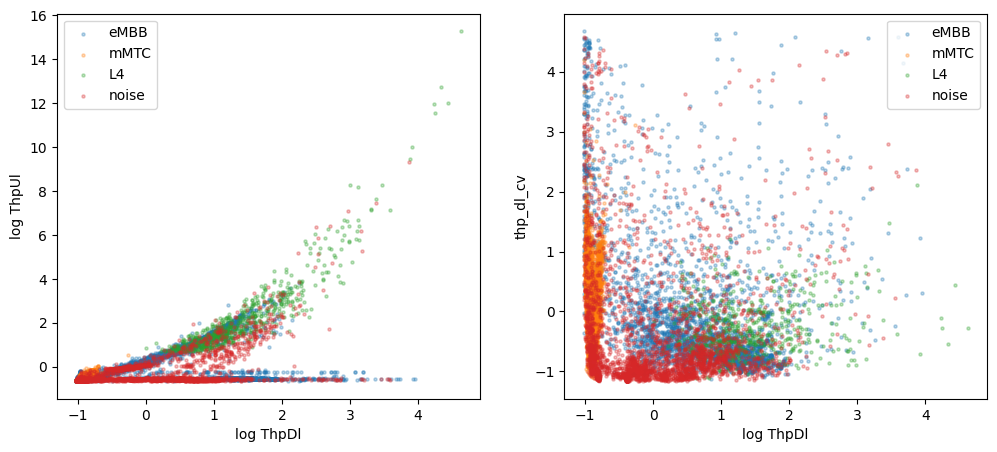

In [38]:
import matplotlib.pyplot as plt
Xs, _ = prepare_features(X_train_bal, "log1p", SCALERS["standard"], log_cols=log_cols)
fig, ax = plt.subplots(1, 2, figsize=(12,5))
for c, name in [(0,'eMBB'),(1,'mMTC'),(4,'L4'),(5,'noise')]:
    m = y_train_bal == c
    ax[0].scatter(Xs[m,0], Xs[m,1], s=5, alpha=0.3, label=name)   # ThpDl vs ThpUl
    ax[1].scatter(Xs[m,0], Xs[m,4], s=5, alpha=0.3, label=name)   # ThpDl vs cv
ax[0].set_xlabel('log ThpDl'); ax[0].set_ylabel('log ThpUl'); ax[0].legend()
ax[1].set_xlabel('log ThpDl'); ax[1].set_ylabel('thp_dl_cv'); ax[1].legend()
plt.show()

#### Tree-based models

In [41]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report

# ---- features & labels (raw; trees don't need log/scale) ----
features = ['DRB.UEThpDl', 'DRB.UEThpUl', 'prb_ul_per_thp',
            'delay_median_w5', 'thp_dl_cv_w5', 'thp_dl_range_w5']
X = df_0145[features]
y = df_0145['label'].astype(int)

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.10, random_state=0, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp)

labels = sorted(y.unique())                 # [0,1,4,5]
names  = {0:'eMBB', 1:'mMTC', 4:'L4', 5:'noise'}

# ---- models ----
# class_weight='balanced' counters the 61/32/5/1 imbalance without resampling.
models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=0),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight='balanced',
        n_jobs=-1, random_state=0),
    "LogReg": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced',
                           multi_class='multinomial')),
}

# ---- optional: XGBoost if installed ----
try:
    from xgboost import XGBClassifier
    # remap labels to 0..3 for xgboost, invert after
    lab2idx = {l:i for i,l in enumerate(labels)}
    idx2lab = {i:l for l,i in lab2idx.items()}
    sample_w = pd.Series(y_train).map(
        {l: len(y_train)/ (len(labels)*c)
         for l,c in y_train.value_counts().items()}).values
    models["XGBoost"] = ("xgb", XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='mlogloss', n_jobs=-1, random_state=0))
except ImportError:
    print("xgboost not installed — skipping (pip install xgboost)")

# ---- run ----
rows = []
for name, mdl in models.items():
    if isinstance(mdl, tuple):              # xgboost special-case
        _, clf = mdl
        clf.fit(X_train, y_train.map(lab2idx), sample_weight=sample_w)
        preds = pd.Series(clf.predict(X_val)).map(idx2lab).values
    else:
        mdl.fit(X_train, y_train)
        preds = mdl.predict(X_val)

    acc = np.mean(preds == y_val.values)
    mf1 = f1_score(y_val, preds, labels=labels, average='macro', zero_division=0)
    rec = recall_score(y_val, preds, labels=labels, average=None, zero_division=0)
    rec_str = "  ".join(f"{names[c]}:{r:.2f}" for c, r in zip(labels, rec))
    print(f"\n=== {name} ===  acc={acc:.4f}  macro_f1={mf1:.4f}")
    print(f"  recall  {rec_str}")

    row = {"model": name, "acc": acc, "macro_f1": mf1}
    row.update({f"recall_{names[c]}": r for c, r in zip(labels, rec)})
    rows.append(row)

    # confusion matrix
    cm = confusion_matrix(y_val, preds, labels=labels)
    print(pd.DataFrame(cm,
        index=[f"true_{names[c]}" for c in labels],
        columns=[f"→{names[c]}" for c in labels]))

    
    print(classification_report(y_val, preds, labels=[0,1,4,5], 
                                target_names=['eMBB','mMTC','L4','noise'], zero_division=0, digits=3))

summary = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
print("\n", summary.to_string(index=False))


=== DecisionTree ===  acc=0.9158  macro_f1=0.7210
  recall  eMBB:0.81  mMTC:0.99  L4:0.74  noise:0.80
            →eMBB  →mMTC  →L4  →noise
true_eMBB     134      1   16      15
true_mMTC       5   1846    0      14
true_L4         4      0   25       5
true_noise    127     21   47     770
              precision    recall  f1-score   support

        eMBB      0.496     0.807     0.615       166
        mMTC      0.988     0.990     0.989      1865
          L4      0.284     0.735     0.410        34
       noise      0.958     0.798     0.871       965

    accuracy                          0.916      3030
   macro avg      0.682     0.833     0.721      3030
weighted avg      0.944     0.916     0.924      3030


=== RandomForest ===  acc=0.9587  macro_f1=0.7885
  recall  eMBB:0.72  mMTC:0.99  L4:0.38  noise:0.95
            →eMBB  →mMTC  →L4  →noise
true_eMBB     119      2    3      42
true_mMTC       0   1853    0      12
true_L4         3      0   13      18
true_noise     23

/home/lapdk/workspace/oai-v210/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== LogReg ===  acc=0.8835  macro_f1=0.6508
  recall  eMBB:0.51  mMTC:1.00  L4:0.91  noise:0.73
            →eMBB  →mMTC  →L4  →noise
true_eMBB      84      4   34      44
true_mMTC       4   1858    0       3
true_L4         3      0   31       0
true_noise    168     37   56     704
              precision    recall  f1-score   support

        eMBB      0.324     0.506     0.395       166
        mMTC      0.978     0.996     0.987      1865
          L4      0.256     0.912     0.400        34
       noise      0.937     0.730     0.821       965

    accuracy                          0.883      3030
   macro avg      0.624     0.786     0.651      3030
weighted avg      0.921     0.883     0.895      3030


=== XGBoost ===  acc=0.9561  macro_f1=0.8373
  recall  eMBB:0.84  mMTC:0.99  L4:0.79  noise:0.91
            →eMBB  →mMTC  →L4  →noise
true_eMBB     139      1    5      21
true_mMTC       2   1852    0      11
true_L4         2      0   27       5
true_noise     55     15   1

In [42]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report

# ---- features & labels (raw; trees don't need log/scale) ----
features = ['DRB.UEThpDl', 'DRB.UEThpUl', 'prb_ul_per_thp',
            'delay_median_w5', 'thp_dl_cv_w5', 'thp_dl_range_w5']
X = df_0145[features]
y = df_0145['label'].astype(int)

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.10, random_state=0, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp)

labels = sorted(y.unique())                 # [0,1,4,5]
names  = {0:'eMBB', 1:'mMTC', 4:'L4', 5:'noise'}

# ---- models ----
# class_weight='balanced' counters the 61/32/5/1 imbalance without resampling.
# Models needing scaled input (MLP, kNN, LogReg, NB) are wrapped in a pipeline
# with StandardScaler; tree models get raw features.
models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=0),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight='balanced',
        n_jobs=-1, random_state=0),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        n_jobs=-1, random_state=0),
    "HistGB": HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.1, max_iter=400,
        class_weight='balanced', random_state=0),
    "LogReg": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced')),
    "MLP": make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                      early_stopping=True, random_state=0)),
    "kNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)),
    "GaussianNB": make_pipeline(
        StandardScaler(), GaussianNB()),
}

# ---- optional: LightGBM if installed ----
try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        class_weight='balanced', n_jobs=-1, random_state=0, verbose=-1)
except ImportError:
    print("lightgbm not installed — skipping (pip install lightgbm)")

# ---- optional: XGBoost if installed ----
try:
    from xgboost import XGBClassifier
    # remap labels to 0..3 for xgboost, invert after
    lab2idx = {l:i for i,l in enumerate(labels)}
    idx2lab = {i:l for l,i in lab2idx.items()}
    sample_w = pd.Series(y_train).map(
        {l: len(y_train)/ (len(labels)*c)
         for l,c in y_train.value_counts().items()}).values
    models["XGBoost"] = ("xgb", XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='mlogloss', n_jobs=-1, random_state=0))
except ImportError:
    print("xgboost not installed — skipping (pip install xgboost)")

# ---- run ----
rows = []
for name, mdl in models.items():
    if isinstance(mdl, tuple):              # xgboost special-case
        _, clf = mdl
        clf.fit(X_train, y_train.map(lab2idx), sample_weight=sample_w)
        preds = pd.Series(clf.predict(X_val)).map(idx2lab).values
    else:
        mdl.fit(X_train, y_train)
        preds = mdl.predict(X_val)

    acc = np.mean(preds == y_val.values)
    mf1 = f1_score(y_val, preds, labels=labels, average='macro', zero_division=0)
    rec = recall_score(y_val, preds, labels=labels, average=None, zero_division=0)
    rec_str = "  ".join(f"{names[c]}:{r:.2f}" for c, r in zip(labels, rec))
    print(f"\n=== {name} ===  acc={acc:.4f}  macro_f1={mf1:.4f}")
    print(f"  recall  {rec_str}")

    row = {"model": name, "acc": acc, "macro_f1": mf1}
    row.update({f"recall_{names[c]}": r for c, r in zip(labels, rec)})
    rows.append(row)

    # confusion matrix
    cm = confusion_matrix(y_val, preds, labels=labels)
    print(pd.DataFrame(cm,
        index=[f"true_{names[c]}" for c in labels],
        columns=[f"→{names[c]}" for c in labels]))

    print(classification_report(y_val, preds, labels=[0,1,4,5],
                                target_names=['eMBB','mMTC','L4','noise'], zero_division=0, digits=3))

summary = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
print("\n", summary.to_string(index=False))

lightgbm not installed — skipping (pip install lightgbm)

=== DecisionTree ===  acc=0.9158  macro_f1=0.7210
  recall  eMBB:0.81  mMTC:0.99  L4:0.74  noise:0.80
            →eMBB  →mMTC  →L4  →noise
true_eMBB     134      1   16      15
true_mMTC       5   1846    0      14
true_L4         4      0   25       5
true_noise    127     21   47     770
              precision    recall  f1-score   support

        eMBB      0.496     0.807     0.615       166
        mMTC      0.988     0.990     0.989      1865
          L4      0.284     0.735     0.410        34
       noise      0.958     0.798     0.871       965

    accuracy                          0.916      3030
   macro avg      0.682     0.833     0.721      3030
weighted avg      0.944     0.916     0.924      3030


=== RandomForest ===  acc=0.9587  macro_f1=0.7885
  recall  eMBB:0.72  mMTC:0.99  L4:0.38  noise:0.95
            →eMBB  →mMTC  →L4  →noise
true_eMBB     119      2    3      42
true_mMTC       0   1853    0      1

In [45]:
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# ---- data ----
features = ['DRB.UEThpDl', 'DRB.UEThpUl', 'prb_ul_per_thp',
            'delay_median_w5', 'thp_dl_cv_w5', 'thp_dl_range_w5']
X = df_0145[features]
y = df_0145['label'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.10, random_state=0, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp)

# CV folds over train+val (tuning); test held out for final report
X_dev = pd.concat([X_train, X_val]); y_dev = pd.concat([y_train, y_val])

labels = sorted(y.unique())               # [0,1,4,5]
names  = {0:'eMBB', 1:'mMTC', 4:'L4', 5:'noise'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# ---- search space (targets L4 over-prediction: leaf size, depth, reg, rate) ----
param_dist = {
    "learning_rate":     uniform(0.02, 0.28),      # 0.02–0.30
    "max_iter":          randint(200, 800),
    "max_leaf_nodes":    randint(15, 63),
    "max_depth":         randint(4, 12),
    "min_samples_leaf":  randint(20, 200),         # larger leaf -> less L4 over-fit
    "l2_regularization": uniform(0.0, 5.0),
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=0),
    param_distributions=param_dist,
    n_iter=60,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=0,
    verbose=1,
    refit=True,
)
search.fit(X_dev, y_dev)

print("\nBest CV macro-F1: %.4f" % search.best_score_)
print("Best params:", search.best_params_)

# ---- evaluate best model on the HELD-OUT TEST set ----
best = search.best_estimator_
preds = best.predict(X_test)

acc = np.mean(preds == y_test.values)
mf1 = f1_score(y_test, preds, labels=labels, average='macro', zero_division=0)
print(f"\n=== HistGB (tuned) on TEST ===  acc={acc:.4f}  macro_f1={mf1:.4f}")
cm = confusion_matrix(y_test, preds, labels=labels)
print(pd.DataFrame(cm, index=[f"true_{names[c]}" for c in labels],
                       columns=[f"→{names[c]}" for c in labels]))
print(classification_report(y_test, preds, labels=labels,
      target_names=[names[c] for c in labels], zero_division=0, digits=3))

Fitting 5 folds for each of 60 candidates, totalling 300 fits



Best CV macro-F1: 0.8173
Best params: {'l2_regularization': np.float64(4.45961677507836), 'learning_rate': np.float64(0.245734316932904), 'max_depth': 11, 'max_iter': 755, 'max_leaf_nodes': 47, 'min_samples_leaf': 31}

=== HistGB (tuned) on TEST ===  acc=0.9518  macro_f1=0.8193
            →eMBB  →mMTC  →L4  →noise
true_eMBB     147      0    8      11
true_mMTC       6   1851    0       9
true_L4         1      0   30       2
true_noise     66     13   30     857
              precision    recall  f1-score   support

        eMBB      0.668     0.886     0.762       166
        mMTC      0.993     0.992     0.992      1866
          L4      0.441     0.909     0.594        33
       noise      0.975     0.887     0.929       966

    accuracy                          0.952      3031
   macro avg      0.769     0.918     0.819      3031
weighted avg      0.963     0.952     0.955      3031



#### Prediction

In [49]:
import joblib
import numpy as np
import time

# =====================================================
# 1. SAVE — after search.fit, persist the best estimator + metadata
# =====================================================
best = search.best_estimator_

# Bundle the model with the exact feature order and label set it expects,
# so the loader can't silently feed columns in the wrong order.
artifact = {
    "model": best,
    "features": ['DRB.UEThpDl', 'DRB.UEThpUl', 'prb_ul_per_thp',
                 'delay_median_w5', 'thp_dl_cv_w5', 'thp_dl_range_w5'],
    "labels": [0, 1, 4, 5],
    "label_names": {0: 'eMBB', 1: 'mMTC', 4: 'L4', 5: 'noise'},
    "params": search.best_params_,
}
joblib.dump(artifact, "smartgw_histgb.pkl", compress=3)
print("Saved -> smartgw_histgb.pkl")


# =====================================================
# 2. LOAD
# =====================================================
artifact = joblib.load("smartgw_histgb.pkl")
model    = artifact["model"]
FEATURES = artifact["features"]
NAMES    = artifact["label_names"]


# =====================================================
# 3. PREDICT with latency
# =====================================================
def predict_with_latency(model, X):
    """X: DataFrame or 2D array with columns in FEATURES order."""
    Xin = X[FEATURES]
    t0 = time.perf_counter()
    preds = model.predict(Xin)
    t1 = time.perf_counter()
    return preds, (t1 - t0)

Saved -> smartgw_histgb.pkl


In [52]:
# ---- batch latency (whole test set at once) ----
preds, dt = predict_with_latency(model, X_test)
print(f"Batch: {len(X_test)} samples in {dt*1e3:.2f} ms "
      f"({dt/len(X_test)*1e6:.2f} µs/sample)")

# ---- single-sample latency (realistic per-flow routing cost) ----
# Averaged over many single predictions; first call is warmed up separately.
one = X_test.iloc[[0]][FEATURES]
model.predict(one)                         # warm-up (excluded from timing)

N = 1000
t0 = time.perf_counter()
for i in range(N):
    model.predict(X_test.iloc[[i % len(X_test)]][FEATURES]) 
t1 = time.perf_counter()
print(f"Single-sample: {(t1-t0)/N*1e3:.4f} ms/sample "
      f"(avg over {N} calls)")

Batch: 3031 samples in 5.25 ms (1.73 µs/sample)
Single-sample: 1.0732 ms/sample (avg over 1000 calls)


In [54]:
"""
SmartGW traffic classifier — prediction with custom input.
Loads the saved HistGB model and classifies KPM samples into
eMBB / mMTC / L4 / noise.
"""
import joblib
import numpy as np
import pandas as pd
import time
from collections import deque, defaultdict

# =====================================================
# Load model
# =====================================================
artifact  = joblib.load("smartgw_histgb.pkl")
model     = artifact["model"]
FEATURES  = artifact["features"]          # order the model expects
NAMES     = artifact["label_names"]       # {0:'eMBB',1:'mMTC',4:'L4',5:'noise'}
W = 5                                      # window used in training
EPS = 1e-6

# =====================================================
# Feature engineering — reproduce EXACTLY what training did.
# Stateless ratio is direct; windowed features need per-UE history.
# =====================================================
# per-UE rolling buffers for the windowed features
_thp_hist   = defaultdict(lambda: deque(maxlen=W))   # DRB.UEThpDl history
_delay_hist = defaultdict(lambda: deque(maxlen=W))   # DRB.RlcSduDelayDl history

def build_feature_row(sample, ue_id=1):
    """
    sample: dict of raw KPM values. Required raw keys:
        'DRB.UEThpDl', 'DRB.UEThpUl', 'RRU.PrbTotUl', 'DRB.RlcSduDelayDl'
    Returns a 1-row DataFrame with the 6 model features, or None if the
    UE's window isn't full yet (cold start -> can't classify).
    """
    thp_dl = sample['DRB.UEThpDl']
    thp_ul = sample['DRB.UEThpUl']
    prb_ul = sample['RRU.PrbTotUl']
    delay  = sample['DRB.RlcSduDelayDl']

    # update per-UE history
    _thp_hist[ue_id].append(thp_dl)
    _delay_hist[ue_id].append(delay)

    # cold start: window not full -> match training's drop policy
    if len(_thp_hist[ue_id]) < W:
        return None

    thp_arr = np.array(_thp_hist[ue_id])
    row = {
        'DRB.UEThpDl':     thp_dl,
        'DRB.UEThpUl':     thp_ul,
        'prb_ul_per_thp':  prb_ul / (thp_ul + EPS),
        'delay_median_w5': float(np.median(_delay_hist[ue_id])),
        'thp_dl_cv_w5':    float(thp_arr.std() / (thp_arr.mean() + EPS)),
        'thp_dl_range_w5': float(thp_arr.max() - thp_arr.min()),
    }
    return pd.DataFrame([row])[FEATURES]     # correct column order + names

# =====================================================
# Predict a single custom sample
# =====================================================
def classify(sample, ue_id=1, measure_latency=False):
    Xrow = build_feature_row(sample, ue_id)
    if Xrow is None:
        return {"status": "warming_up",
                "seen": len(_thp_hist[ue_id]), "need": W}

    if measure_latency:
        model.predict(Xrow)                  # warm-up
        t0 = time.perf_counter()
        pred = model.predict(Xrow)[0]
        dt = (time.perf_counter() - t0) * 1e3
    else:
        pred = model.predict(Xrow)[0]
        dt = None

    out = {"status": "ok",
           "label": int(pred),
           "class": NAMES.get(int(pred), f"unknown({int(pred)})")}
    if measure_latency:
        out["latency_ms"] = round(dt, 4)
    return out


# =====================================================
# EXAMPLE — feed your own raw KPM values here
# =====================================================
if __name__ == "__main__":
    # A stream of raw KPM samples for one UE. The first W-1 return
    # "warming_up"; classification starts once the window fills.
    stream = [
        {'DRB.UEThpDl': 5322.0, 'DRB.UEThpUl': 205.0,
         'RRU.PrbTotUl': 3024.0, 'DRB.RlcSduDelayDl': 98.0},
        {'DRB.UEThpDl': 4800.0, 'DRB.UEThpUl': 180.0,
         'RRU.PrbTotUl': 2900.0, 'DRB.RlcSduDelayDl': 95.0},
        {'DRB.UEThpDl': 5100.0, 'DRB.UEThpUl': 190.0,
         'RRU.PrbTotUl': 3100.0, 'DRB.RlcSduDelayDl': 100.0},
        {'DRB.UEThpDl': 5000.0, 'DRB.UEThpUl': 200.0,
         'RRU.PrbTotUl': 3000.0, 'DRB.RlcSduDelayDl': 97.0},
        {'DRB.UEThpDl': 5250.0, 'DRB.UEThpUl': 195.0,
         'RRU.PrbTotUl': 3050.0, 'DRB.RlcSduDelayDl': 96.0},   # window full here
    ]

    for i, s in enumerate(stream):
        result = classify(s, ue_id=1, measure_latency=True)
        print(f"sample {i}: {result}")

sample 0: {'status': 'warming_up', 'seen': 1, 'need': 5}
sample 1: {'status': 'warming_up', 'seen': 2, 'need': 5}
sample 2: {'status': 'warming_up', 'seen': 3, 'need': 5}
sample 3: {'status': 'warming_up', 'seen': 4, 'need': 5}
sample 4: {'status': 'ok', 'label': 5, 'class': 'noise', 'latency_ms': 0.7864}
